# Whose monthly spend fell two months running?

**Week 2, Wednesday. Chapter 4 of 6.** Chapters 1 to 3 built the protect list; this chapter
answers Marketing's second ask, the flag.

> "... and flag anyone whose monthly spend has fallen for two months running."
> The marketing lead, Kalpa Retail

**Who needs the answer.** The marketing lead's member team will ring each flagged member with
a retention offer before their buying drifts further. A flag that names the wrong member
costs a call and tells a loyal customer they are slipping; a fall the flag misses is a member
nobody rang until they had gone.

**The questions on the way.**
1. Which ways could the team set each month beside the month before, and what would each cost?
2. What did each member spend in each month?
3. What does LAG put beside one member's months?
4. What does LAG read when the window has no PARTITION BY?
5. How many members fell two months running once each member's months are kept apart?
6. Does a walk through each member's months in Python find the same members?

**The metric at stake.** Monthly spend: a member's booked revenue in one calendar month,
every order at its amount whatever its status. The book runs from April to September 2026,
and the flag reads September, the last month: spend in September below the month before, and
that month below the one before it. The retail dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, section 5, has how
often a customer orders and why a membership tier watches it.

**What did chapters 1 to 3 find?** Each segment has its own protect list of fifty members, or
every buyer where a segment has fewer than fifty, cut by RANK so that members who spent the
same share a place, as the head of Retail-Plus asked: Business 35 and Student 20, every Q2
buyer in both, Retail-Core 50, and Retail-Plus the count each learner read in their own run.
That list says who matters most; this chapter asks whose spend is slipping.

**A real company with the same question.** Square, the point-of-sale company, gives its
sellers a ready-made "Lapsed" group: "customers who were regulars, but haven't visited in
the last six weeks", where a regular visited three times in the last six months (Square
Support Center, the page on customer groups and filters, checked 1 October 2026). Each
customer is judged against their own earlier pattern, which is what Marketing's flag does
with monthly spend.

**Setup.** The next cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`, connects to the Kalpa warehouse and reads the named queries in
`../sql/C2_W02_D03_04_falling_spend_STUDENT.sql`. Every query below is a block of that file, so what
runs here is exactly what runs from VS Code. If no database answers, the error names the
command that loads the warehouse: `bash .devcontainer/load_warehouse.sh`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D03_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]

def show(found, caption="", money=(), limit=12):
    """Rows as the kit's table, with the columns named in money set in rupees."""
    if not found:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(found[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in found[:limit]]
    if len(found) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12, echo=True):
    """Print a named block, run it, show its rows and hand them back."""
    if echo:
        print(Q[name])
    found = rows(Q[name])
    show(found, caption, money, limit)
    return found

def lakh(v):
    """Rupees in lakh, for an axis that has to hold Business and retail members at once."""
    return f"{v / 100000:,.1f} lakh"

Q = blocks("04_falling_spend")
print(len(Q), "named queries read from", "C2_W02_D03_04_falling_spend_STUDENT.sql;",
      kit.sql("select version()")[0]["version"].split(",")[0])

10 named queries read from C2_W02_D03_04_falling_spend_STUDENT.sql; PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


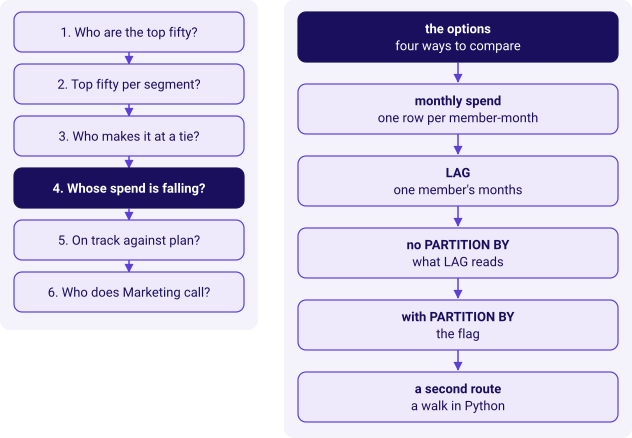

In [2]:
kit.side_by_side(
    kit.ladder(['Who are the top fifty?', 'Top fifty per segment?', 'Who makes it at a tie?', 'Whose spend is falling?', 'On track against plan?', 'Who does Marketing call?'], lit=3, show=False),
    kit.vflow(['the options\nfour ways to compare', 'monthly spend\none row per member-month', "LAG\none member's months", 'no PARTITION BY\nwhat LAG reads', 'with PARTITION BY\nthe flag', 'a second route\na walk in Python'], lit=0, show=False),
)

## The options: which ways could the team set each month beside the month before, and what would each cost?

The flag compares three months of one member. Each option has to put a month's spend beside
the two before it.

| Option | How it sets a month beside the one before | Statements | What the database works through | What it has to be told |
|---|---|---|---|---|
| A. LAG in a window | reads the row before in the order the window names | 1 | every member-month, once | whose rows belong together and in what order |
| B. A self-join of the monthly table to itself | joins each month to the same member's month one and two before | 1, with two joins | every member-month matched against the table, twice | the month arithmetic |
| C. A correlated subquery per month | looks up the month before, row by row | 1 | two lookups for every member-month | the lookup's conditions, twice |
| D. Months as spreadsheet columns, read by eye | reads across each member's row | none | every member times six months, exported | a person to read every row |

**Predict before you run.** How many member-months, one row per member per month with an
order, does the book hold from April to September?

- a) 1,000, one per order.
- b) 752.
- c) 301, one per member who bought.
- d) 6, one per month.

option,"rows, matches or cells worked through"
A. LAG in a window,752
"B. self-join, twice","1,504"
C. two lookups per row,"1,504"
D. spreadsheet cells,"1,806"


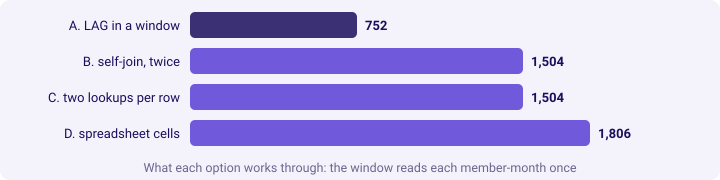

In [3]:
size = rows(Q["c4_monthly_count"])[0]
sizing = [("A. LAG in a window", size["member_months"]),
          ("B. self-join, twice", 2 * size["member_months"]),
          ("C. two lookups per row", 2 * size["member_months"]),
          ("D. spreadsheet cells", 6 * size["members"])]
kit.table(["option", "rows, matches or cells worked through"], [(o, f"{n:,}") for o, n in sizing],
          caption=f"Sized on this book: {size['member_months']} member-months for {size['members']} members")
kit.bars(sizing, title="What each option works through: the window reads each member-month once", lit=(0,))

**What happened.** The answer is b: 752 member-months for 301 members who bought at least
once. LAG reads them once; the self-join looks each one up twice and the correlated subquery
does the same, 1,504 lookups each; the spreadsheet holds 1,806 cells for someone to read.

**The best-fit call.** Option A, LAG in a window: one pass, one statement, and `lag(spend, 2)`
reaches two months back in the same statement as `lag(spend, 1)`. What would change the call
is a database with no window functions, such as a MySQL server older than version 8.0, which
leaves a lookup per row, option C, a correlated subquery that finds each member's previous
month with an order.

In [4]:
kit.check("752 member-months for 301 members", (size["member_months"], size["members"]) == (752, 301))
kit.check("118 members ordered in September, the month the flag reads",
          size["members_with_a_september_order"] == 118)
kit.check("the window works through the fewest rows", sizing[0][1] == min(n for _, n in sizing))

## 1. What did each member spend in each month?

The orders table holds one row per order, so monthly spend is grouped by member and by the
month each order fell in. `date_trunc('month', order_date)` turns every date into the first
day of its month, so all of a month's orders share one key.

**Predict before you run.** Roughly how many members placed an order in each month?

- a) About 120 a month, steady across the six months.
- b) About 300, nearly every member every month.
- c) About 30.
- d) It halves from April to September.

-- The question: what did each member spend in each month they bought? One row per member per month
-- with an order; this shows the first twelve.
SELECT customer_id,
       date_trunc('month', order_date)::date AS month,
       sum(amount)                           AS spend
FROM   orders
GROUP  BY customer_id, date_trunc('month', order_date)
ORDER  BY customer_id, month
LIMIT  12;


customer_id,month,spend
C-0001,2026-04-01,"Rs 1,640"
C-0001,2026-08-01,"Rs 1,200"
C-0002,2026-04-01,Rs 800
C-0002,2026-05-01,"Rs 1,560"
C-0002,2026-06-01,"Rs 1,670"
C-0002,2026-07-01,"Rs 2,670"
C-0003,2026-04-01,"Rs 3,850"
C-0003,2026-06-01,"Rs 2,420"
C-0003,2026-07-01,"Rs 2,630"
C-0003,2026-08-01,Rs 810


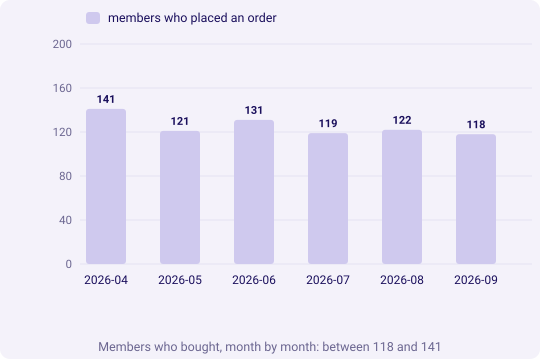

In [5]:
run("c4_monthly", "The first twelve member-months", money=("spend",))
buyers = rows(Q["c4_buyers_by_month"])
kit.columns([str(r["month"])[:7] for r in buyers],
            [("members who placed an order", [r["members_who_bought"] for r in buyers])],
            title="Members who bought, month by month: between 118 and 141")

**What happened.** The answer is a: between 118 and 141 members bought in each month, from
141 in April to 118 in September. Each member's months sit on separate rows, one row per
month with an order, which is the shape LAG reads.

In [6]:
kit.check("between 118 and 141 members bought each month",
          min(r["members_who_bought"] for r in buyers) == 118 and max(r["members_who_bought"] for r in buyers) == 141)
kit.check("six months on the book", len(buyers) == 6)

## 2. What does LAG put beside one member's months?

`lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month)` puts the previous row's spend
beside each row, counting rows inside the member's own months in month order, and
`lag(spend, 2)` reads two rows back. C-0040 of Retail-Core bought in all six months.

**Predict before you run.** What does `lag(spend, 1)` show on C-0040's first month, April?

- a) 0.
- b) NULL, since no row comes before it.
- c) September's spend, the last row.
- d) April's own spend.

-- The question: what does LAG put beside each of one member's months? C-0040, Retail-Core, who
-- bought in all six months.
WITH monthly AS (
    SELECT customer_id, date_trunc('month', order_date)::date AS month, sum(amount) AS spend
    FROM   orders
    GROUP  BY customer_id, date_trunc('month', order_date)
)
SELECT customer_id, month, spend,
       lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS spend_1_back,
       lag(spend, 2) OVER (PARTITION BY customer_id ORDER BY month) AS spend_2_back
FROM   monthly
WHERE  customer_id = 'C-0040'
ORDER  BY month;


customer_id,month,spend,spend_1_back,spend_2_back
C-0040,2026-04-01,"Rs 7,980",NULL,NULL
C-0040,2026-05-01,"Rs 3,170","Rs 7,980",NULL
C-0040,2026-06-01,"Rs 1,320","Rs 3,170","Rs 7,980"
C-0040,2026-07-01,"Rs 4,260","Rs 1,320","Rs 3,170"
C-0040,2026-08-01,"Rs 4,770","Rs 4,260","Rs 1,320"
C-0040,2026-09-01,"Rs 4,520","Rs 4,770","Rs 4,260"


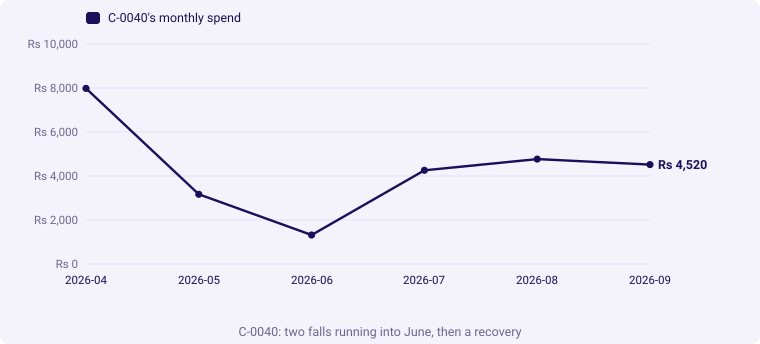

In [7]:
one = run("c4_one_member", "C-0040's six months, with LAG one and two rows back", money=("spend", "spend_1_back", "spend_2_back"))
kit.line([str(r["month"])[:7] for r in one], [("C-0040's monthly spend", [r["spend"] for r in one], "lit")],
         title="C-0040: two falls running into June, then a recovery", fmt=kit.rupees)

**What happened.** The answer is b: NULL, since April is the first row of C-0040's months,
and May shows NULL two rows back for the same reason. June carries May's Rs 3,170 and April's
Rs 7,980 beside its own Rs 1,320: two falls running, so a flag read at June would fire.
September's Rs 4,520 is below August's Rs 4,770, but August was above July's Rs 4,260, so the
flag read at September does not fire for C-0040.

In [8]:
kit.check("the first month has nothing before it", one[0]["spend_1_back"] is None and one[0]["spend_2_back"] is None)
kit.check("June sits beside May and April", (one[2]["spend_1_back"], one[2]["spend_2_back"]) == (3170, 7980))
kit.check("C-0040's September is not a second fall", not (one[5]["spend"] < one[5]["spend_1_back"] < one[5]["spend_2_back"]))

## 3. What does LAG read when the window has no PARTITION BY?

The quickest flag sorts the whole table by member and month and lets LAG run down it:

```sql
lag(spend, 1) OVER (ORDER BY customer_id, month) AS spend_1_back,
lag(spend, 2) OVER (ORDER BY customer_id, month) AS spend_2_back
...
WHERE month = DATE '2026-09-01' AND spend < spend_1_back AND spend_1_back < spend_2_back
```

**Predict before you run.** Against the version with PARTITION BY, does the quick version
flag more members, fewer, or the same?

- a) The same, since the sort already keeps each member's months together.
- b) More.
- c) Fewer.
- d) None at all, since LAG needs a partition to run.

In [9]:
hurried = rows(Q["c4_hurried"])[0]["members_flagged"]
checked = rows(Q["c4_hurried_check"])[0]
kit.stats([(hurried, "members flagged", "LAG with no PARTITION BY"),
           (checked["compared_with_another_member"], "of them", "compared with another member's month")],
          caption="The plausible wrong answer: 20 members flagged")
crossings = run("c4_crossings", "The four flags that read another member's month",
                money=("spend", "spend_1_back", "spend_2_back"), echo=False)

customer_id,spend,spend_1_back,member_1_back,spend_2_back,member_2_back,month_2_back
C-0070,"Rs 1,260","Rs 1,470",C-0070,"Rs 2,650",C-0068,2026-09-01
C-0117,"Rs 1,400","Rs 1,760",C-0117,"Rs 4,770",C-0116,2026-08-01
C-0132,"Rs 1,920","Rs 2,620",C-0132,"Rs 4,700",C-0131,2026-07-01
C-0335,Rs 750,Rs 900,C-0335,"Rs 2,150",C-0334,2026-08-01


**The plausible wrong answer.** The quick version flags 20 members as falling two months
running. The answer to the prediction is b.

**Why it is wrong.** With no PARTITION BY the window is the whole table, so LAG runs straight
from one member's last row into the next member's first. A member with fewer than three
months borrows the months of whoever sorts before them. C-0132 of Retail-Core bought in July
(Rs 2,620) and September (Rs 1,920), and LAG's second step back read C-0131's July, Rs 4,700,
so C-0132 would get a call about a fall from a month that belongs to someone else. Four of the
twenty flags are made this way.

**The check that exposes it.** Carry `lag(customer_id)` beside `lag(spend)` and count the
flags where the member LAG read is not the member on the row; it should be zero, and it is
four.

In [10]:
kit.check("the check finds the four flags that crossed into another member",
          checked["compared_with_another_member"] == 4 and len(crossings) == 4)
kit.check("every crossing read the member who sorts just before",
          all(r["member_2_back"] != r["customer_id"] for r in crossings))

## 4. How many members fell two months running once each member's months are kept apart?

**The fix.** PARTITION BY customer_id starts the window again for every member, so LAG
returns NULL on a member's first row and never reaches into another member's months.

```sql
lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS spend_1_back
```

**Predict before you run.** How many members does the partitioned flag keep?

- a) 20, the same members.
- b) 16.
- c) 24.
- d) 4.

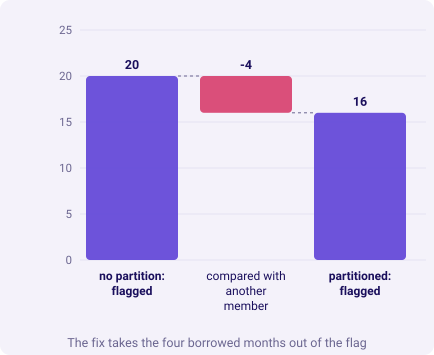

In [11]:
fixed = rows(Q["c4_partitioned"])[0]["members_flagged"]
kit.bridge(("no partition: flagged", hurried), [("compared with another member", -checked["compared_with_another_member"])],
           end_label="partitioned: flagged", title="The fix takes the four borrowed months out of the flag",
           fmt=lambda v: f"{v:,.0f}")

**What happened.** The answer is b: 16 members, out of the 118 who ordered in September,
spent less in September than in their month before, and less in that month than in the one
before it. The fix takes four members off the call list who had been accused with somebody
else's months, 20 less 4.

In [12]:
kit.check("the partitioned flag keeps 16 members", fixed == 16)
kit.check("the fix removes exactly the four crossings", hurried - fixed == checked["compared_with_another_member"])

## A second route: does a walk through each member's months in Python find the same members?

The second route uses no window: it pulls the 752 member-months into Python unordered, groups
them by member in a dictionary, sorts each member's months itself, and flags a member whose
last month is September and whose last three months each fall. A slip in the window's
PARTITION BY or ORDER BY could not move this flag, since the two share no code.

**Predict before you run.** Will the walk flag the same 16 members?

- a) Yes, the same 16.
- b) No, 20, since Python reads the rows in the order they arrive.
- c) No, fewer, since Python drops the NULLs.
- d) Only the Business members.

In [13]:
raw = rows(Q["c4_rows_for_python"])
months = {}
for r in raw:
    months.setdefault(r["customer_id"], []).append((r["month"], r["spend"]))
walk = set()
for cid, rows_of in months.items():
    rows_of.sort()
    if len(rows_of) >= 3 and str(rows_of[-1][0]) == "2026-09-01":
        a, b, c = (s for _, s in rows_of[-3:])
        if c < b < a:
            walk.add(cid)
window = {r["customer_id"] for r in rows(Q["c4_partitioned_ids"])}
kit.table(["route", "member-months read", "members flagged"],
          [("LAG, PARTITION BY customer_id", 752, len(window)), ("Python walk", len(raw), len(walk))],
          caption="Two routes, one flag")
kit.check("Python read every member-month", len(raw) == 752)
kit.check("the walk flags the window's members, no more and no fewer", walk == window, f"{len(walk)} members")

route,member-months read,members flagged
"LAG, PARTITION BY customer_id",752,16
Python walk,752,16


**What happened.** The answer is a: the walk flags the same 16 members as the partitioned
LAG, member for member. Both read "the month before" as the member's previous row of months.

> **Kavya's review.** A window that is not told whose rows belong together will compare
> anyone with anyone. Carry the id LAG read beside the value it read, and read the rows
> behind a flag before a call goes out.

### In the interview: how do you find a fall two months running, and how do you catch LAG crossing customers?

**[F] How would you find customers whose spend fell two months in a row?** Build one row per
customer per month, take `lag(spend, 1)` and `lag(spend, 2)` over a window partitioned by
the customer and ordered by month, and keep the rows where this month is below the last and
the last below the one before. The partition is what keeps each customer's history their
own.

**[F] LAG returned a value for a customer's very first month. What went wrong, and how do you
check for it in ten thousand rows?** Most often the window has no PARTITION BY, so LAG
crossed from the previous customer's last row. Carry `lag(customer_id)` beside the value and
count the rows where it differs from the row's own customer; the count must be zero. Two other
causes give the same symptom, so read the window's call too: a default argument, as in
`lag(spend, 1, 0)`, puts a value on the first row where NULL belongs, and an ORDER BY month
DESC inside the window makes the first month read the month after it.

### Depth: which months fell two running anywhere in the six, and what does LEAD read?

The flag reads September because Marketing acts now. The same window, read at every month,
shows how common a two-month fall is across the book. `lead()` reads the next row the same
way LAG reads the previous one; nothing today needs it.

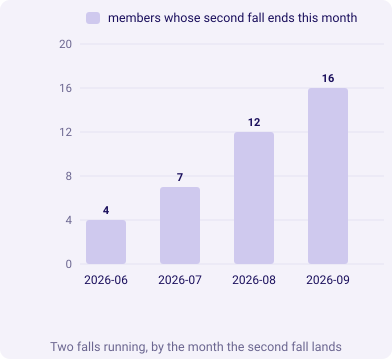

In [14]:
anywhere = rows("""
    WITH monthly AS (
        SELECT customer_id, date_trunc('month', order_date)::date AS month, sum(amount) AS spend
        FROM orders GROUP BY customer_id, date_trunc('month', order_date)),
    lagged AS (
        SELECT customer_id, month, spend,
               lag(spend, 1) OVER (PARTITION BY customer_id ORDER BY month) AS b1,
               lag(spend, 2) OVER (PARTITION BY customer_id ORDER BY month) AS b2
        FROM monthly)
    SELECT to_char(month, 'YYYY-MM') AS month, count(*) AS two_falls_ending_here
    FROM lagged WHERE spend < b1 AND b1 < b2 GROUP BY 1 ORDER BY 1""")
kit.columns([r["month"] for r in anywhere], [("members whose second fall ends this month",
             [r["two_falls_ending_here"] for r in anywhere])],
            title="Two falls running, by the month the second fall lands")
kit.check("September's count is the flag's 16",
          [r["two_falls_ending_here"] for r in anywhere if r["month"] == "2026-09"] == [16])

## So whose monthly spend fell two months running?

1. **Which way, at what cost?** LAG in a window: one pass over 752 member-months, where a
   self-join or a lookup per row works through 1,504.
2. **What did each member spend each month?** One row per member per month with an order:
   752 member-months, with 118 to 141 members buying in each month.
3. **What does LAG put beside a month?** The member's previous row and the one before it;
   C-0040 fell twice running into June and recovered.
4. **What does LAG read with no PARTITION BY?** Another member's months: 20 flags, four of
   them borrowed, caught by carrying the id LAG read.
5. **How many fell two months running?** 16 members, with each member's months kept apart.
6. **Does a Python walk agree?** Yes, the same 16 members.

Chapter 5 turns to Meera's ask: has Q2 revenue kept pace with the plan line? Chapter 6 comes
back to these 16 before Marketing rings any of them.

In [15]:
kit.check_summary()